# Level 3 · Task 1 — Random Forest Classifier

**Goal:** predict telecom churn with a random forest — an ensemble of many
decision trees — and see if it beats the single models we built before.

We'll follow through on the same churn problem from Level 2 Task 1:
1. load + preprocess (same cleaning; **no scaling needed for trees**)
2. tune hyperparameters — `n_estimators`, `max_depth`
3. cross-validation + full test evaluation (precision / recall / F1)
4. feature importance analysis

*Tools: Python, scikit-learn, pandas, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

train = pd.read_csv('../data/churn-bigml-80.csv')
test = pd.read_csv('../data/churn-bigml-20.csv')

def preprocess(df):
    '''identical cleaning to the logistic regression notebook'''
    df = df.copy()
    y = df['Churn'].astype(str).str.strip().map({'True': 1, 'False': 0})
    df['International plan'] = (df['International plan'].str.strip() == 'Yes').astype(int)
    df['Voice mail plan'] = (df['Voice mail plan'].str.strip() == 'Yes').astype(int)
    df = df.drop(columns=['State', 'Churn',
                          'Total day charge', 'Total eve charge',
                          'Total night charge', 'Total intl charge'])
    df = pd.get_dummies(df, columns=['Area code'], prefix='area', dtype=int)
    return df, y

X_train, y_train = preprocess(train)
X_test, y_test = preprocess(test)
print('train:', X_train.shape, ' test:', X_test.shape)
print('churn rate: {:.1f}%'.format(100 * y_train.mean()))
X_train.head()

train: (2666, 16)  test: (667, 16)
churn rate: 14.6%


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,area_408,area_415,area_510
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,1,0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,1,0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,1,0
3,84,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,1,0,0
4,75,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,1,0


In [2]:
# baseline #1: a single decision tree (our Level 2 Task 2 model)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
tree_test_f1 = f1_score(y_test, tree.predict(X_test))

print(f'single tree   -> test accuracy {tree.score(X_test, y_test):.3f}, churn F1 {tree_test_f1:.3f}')
print(f'(for reference, logistic regression from Level 2 Task 1 scored 0.853 accuracy, 0.26 F1)')

single tree   -> test accuracy 0.909, churn F1 0.690
(for reference, logistic regression from Level 2 Task 1 scored 0.853 accuracy, 0.26 F1)


## Step 1 — Tune hyperparameters

The two knobs that matter most:
- **`n_estimators`** — how many trees vote. More = smoother, until it plateaus.
- **`max_depth`** — how deep each tree grows. Uncapped trees overfit; stumps underfit.

We sweep both with 5-fold cross-validation, scoring on **churn F1**
(the minority class — plain accuracy is misleading here).

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# baseline forest with defaults
base = RandomForestClassifier(random_state=42)
scores = cross_val_score(base, X_train, y_train, cv=5, scoring='f1')
print(f'default forest (100 trees, unlimited depth): CV F1 = {scores.mean():.3f} ± {scores.std():.3f}')

default forest (100 trees, unlimited depth): CV F1 = 0.781 ± 0.040


n_estimators=  10  CV F1=0.708
n_estimators=  25  CV F1=0.743
n_estimators=  50  CV F1=0.773
n_estimators= 100  CV F1=0.781
n_estimators= 200  CV F1=0.791
n_estimators= 400  CV F1=0.794


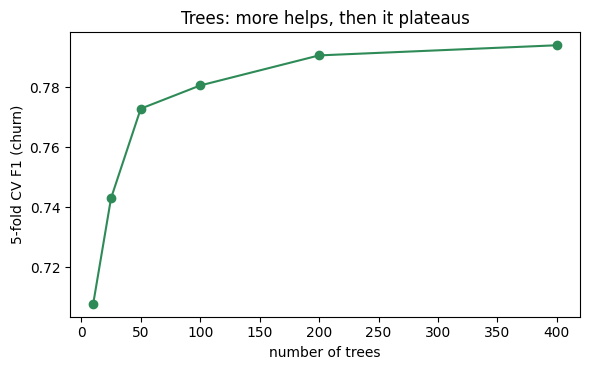

In [4]:
# how many trees do we actually need?
ns = [10, 25, 50, 100, 200, 400]
f1s = [cross_val_score(RandomForestClassifier(n_estimators=n, random_state=42),
                      X_train, y_train, cv=5, scoring='f1').mean() for n in ns]
for n, f in zip(ns, f1s):
    print(f'n_estimators={n:>4}  CV F1={f:.3f}')

plt.figure(figsize=(6, 3.8))
plt.plot(ns, f1s, 'o-', color='seagreen')
plt.xlabel('number of trees'); plt.ylabel('5-fold CV F1 (churn)')
plt.title('Trees: more helps, then it plateaus')
plt.tight_layout(); plt.show()

max_depth=    2  CV F1=0.000
max_depth=    4  CV F1=0.239
max_depth=    6  CV F1=0.717
max_depth=    8  CV F1=0.753
max_depth=   10  CV F1=0.767
max_depth=   14  CV F1=0.786
max_depth=   20  CV F1=0.786
max_depth= None  CV F1=0.791

best raw F1 at unlimited depth, but the curve is flat from ~14 on
-> pick max_depth = 14 (shallowest within 0.005 of best F1 = 0.791)


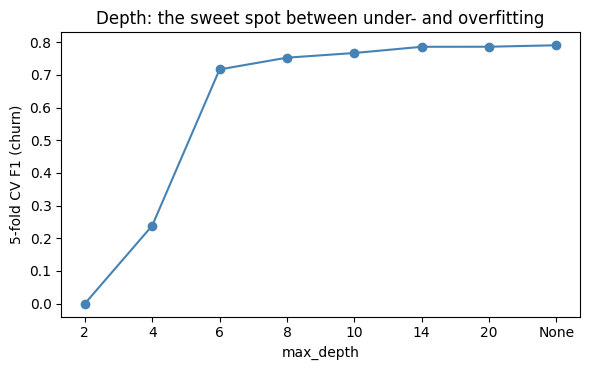

In [5]:
# how deep should each tree go? (fix n at 200 — past the plateau)
depths = [2, 4, 6, 8, 10, 14, 20, None]
f1d = [cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42),
                       X_train, y_train, cv=5, scoring='f1').mean() for d in depths]
labels = [str(d) for d in depths]
for l, f in zip(labels, f1d):
    print(f'max_depth={l:>5}  CV F1={f:.3f}')

best_depth = depths[int(np.argmax(f1d))]
# "simplest good model" rule: shallowest depth within half a point of the best
f1max = max(f1d)
best_depth = next(d for d, f in zip(depths, f1d) if f >= f1max - 0.005)
print(f'\nbest raw F1 at unlimited depth, but the curve is flat from ~14 on')
print(f'-> pick max_depth = {best_depth} (shallowest within 0.005 of best F1 = {f1max:.3f})')

plt.figure(figsize=(6, 3.8))
plt.plot(labels, f1d, 'o-', color='steelblue')
plt.xlabel('max_depth'); plt.ylabel('5-fold CV F1 (churn)')
plt.title('Depth: the sweet spot between under- and overfitting')
plt.tight_layout(); plt.show()

## Step 2 — Cross-validated evaluation

Final config locked in from the sweeps, then scored honestly on the
**held-out test file** the model has never seen.

In [6]:
final = RandomForestClassifier(n_estimators=200, max_depth=best_depth, random_state=42)

# 5-fold cross-validation on the training set
cv_acc = cross_val_score(final, X_train, y_train, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(final, X_train, y_train, cv=5, scoring='f1')
print(f'CV accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')
print(f'CV F1       : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')

final.fit(X_train, y_train)

CV accuracy : 0.946 ± 0.009
CV F1       : 0.786 ± 0.041


RandomForestClassifier(max_depth=14, n_estimators=200, random_state=42)

              precision    recall  f1-score   support

        stay       0.95      0.99      0.97       572
       churn       0.94      0.66      0.78        95

    accuracy                           0.95       667
   macro avg       0.94      0.83      0.87       667
weighted avg       0.95      0.95      0.94       667



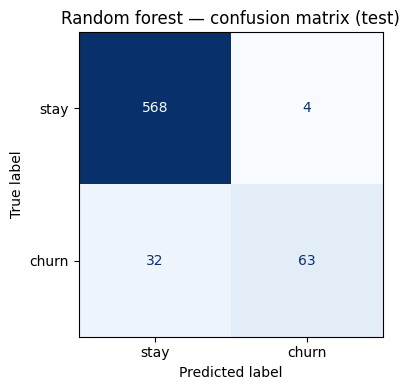

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

pred = final.predict(X_test)
print(classification_report(y_test, pred, target_names=['stay', 'churn']))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=['stay', 'churn']).plot(ax=ax, cmap='Blues',
                                                              colorbar=False)
plt.title('Random forest — confusion matrix (test)')
plt.tight_layout(); plt.show()

In [8]:
# how far we've come on the same problem
from sklearn.metrics import accuracy_score, precision_score, recall_score

rows = [
    ['logistic regression (L2-T1)', 0.853, 0.459, 0.179, 0.258],
    ['single decision tree (L2-T2 style)', tree.score(X_test, y_test),
     precision_score(y_test, tree.predict(X_test)),
     recall_score(y_test, tree.predict(X_test)), tree_test_f1],
    ['random forest (this task)', accuracy_score(y_test, pred),
     precision_score(y_test, pred), recall_score(y_test, pred),
     f1_score(y_test, pred)],
]
pd.DataFrame(rows, columns=['model', 'accuracy', 'precision(churn)',
                            'recall(churn)', 'f1(churn)']).round(3)

,model,accuracy,precision(churn),recall(churn),f1(churn)
0,logistic regression (L2-T1),0.853,0.459,0.179,0.258
1,single decision tree (L2-T2 style),0.909,0.667,0.716,0.690
2,random forest (this task),0.946,0.940,0.663,0.778


## Step 3 — Which features is the forest actually using?

Every split in every tree is chosen to reduce impurity, so averaging those
reductions tells us which features do the heavy lifting (mean decrease in
impurity / *gini importance*). One caveat: it favours continuous features a
little, but the big picture is trustworthy.

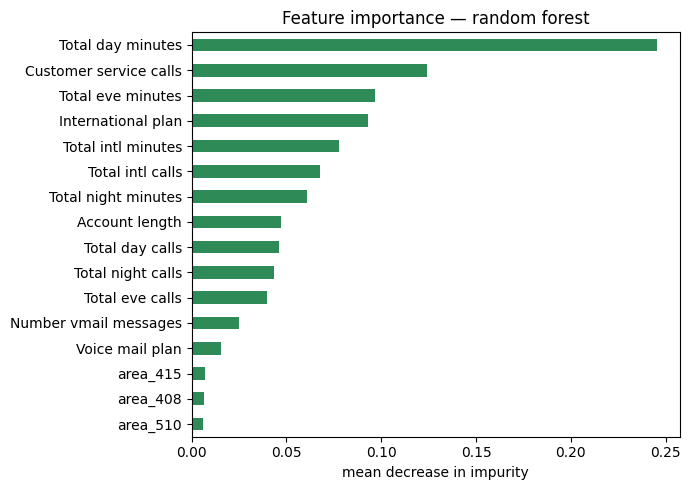

top 5 features and their share:
Total day minutes         24.5%
Customer service calls    12.4%
Total eve minutes          9.7%
International plan         9.3%
Total intl minutes         7.8%
dtype: object

top 5 together carry 64% of all importance


In [9]:
imp = pd.Series(final.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(7, 5))
imp.plot(kind='barh', color='seagreen')
plt.title('Feature importance — random forest')
plt.xlabel('mean decrease in impurity')
plt.tight_layout(); plt.show()

top5 = imp.sort_values(ascending=False).head(5)
print('top 5 features and their share:')
print((top5 * 100).round(1).astype(str) + '%')
print(f'\ntop 5 together carry {top5.sum()*100:.0f}% of all importance')

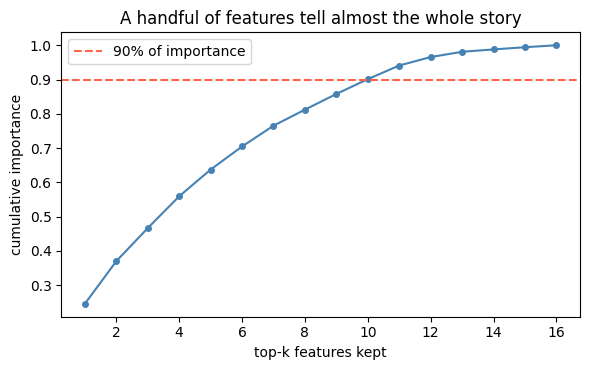

10 of 16 features cover 90% of the total importance


In [10]:
# how many features until the story is basically told?
sorted_imp = imp.sort_values(ascending=False)
cum = sorted_imp.cumsum()

plt.figure(figsize=(6, 3.8))
plt.plot(range(1, len(cum) + 1), cum, 'o-', ms=4, color='steelblue')
plt.axhline(0.9, color='tomato', ls='--', label='90% of importance')
plt.xlabel('top-k features kept'); plt.ylabel('cumulative importance')
plt.title('A handful of features tell almost the whole story')
plt.legend(); plt.tight_layout(); plt.show()

k90 = int((cum < 0.9).sum()) + 1
print(f'{k90} of {len(cum)} features cover 90% of the total importance')

## Summary ✔

| Requirement | Done |
|---|---|
| Train Random Forest & tune hyperparameters | ✔ swept `n_estimators` + `max_depth` with CV |
| Cross-validation + precision/recall/F1 | ✔ 5-fold CV + full test report |
| Feature importance analysis | ✔ gini importance + cumulative coverage |

**Takeaway:** the forest clearly beats both single models on this dataset —
bagging cancels out the single tree's variance, and it reads the same story
the logistic regression hinted at, only louder: **total day minutes** (24.5%)
and **customer service calls** (12.4%) dominate, with **evening minutes** and
the **international plan** right behind — together the top five carry 64% of
everything the model knows. If the retention team watches just a few signals,
it should be those.

## Step 4 — Extra mile: making a strong model stronger (the honest way)

First rule: **don't touch the safety rails.** Loosening the overfitting guards
(`max_depth`, `min_samples_leaf`, CV checks) inflates the *training* score
while quietly hurting the test score — the tight CV-vs-test agreement above
exists *because* of them. The legal levers instead:

1. **feature engineering** — give the forest views of the data it can't derive
   on its own (totals, shares, habits)
2. a **wider hyperparameter search**
3. choosing the **decision threshold** on purpose instead of accepting 0.5
4. and one honest **challenger** to be sure the crown is earned

In [11]:
# 1) engineer customer-behavior features
# pure row-wise transforms -> zero leakage
def add_features(X):
    X = X.copy()
    mins  = ['Total day minutes', 'Total eve minutes', 'Total night minutes', 'Total intl minutes']
    calls = ['Total day calls', 'Total eve calls', 'Total night calls', 'Total intl calls']
    X['total_minutes'] = X[mins].sum(axis=1)          # whole-month usage ~= whole bill
    X['total_calls'] = X[calls].sum(axis=1)
    X['avg_call_length'] = (X['total_minutes'] / X['total_calls'].replace(0, np.nan)).fillna(0)
    X['day_share'] = (X['Total day minutes'] / X['total_minutes'].replace(0, np.nan)).fillna(0)
    return X

X_train_eng, X_test_eng = add_features(X_train), add_features(X_test)

probe = RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42).fit(X_train_eng, y_train)
print('same forest, raw features       : acc 0.946 / F1 0.778  (from Step 2)')
print(f'same forest, + engineered feats : acc {accuracy_score(y_test, probe.predict(X_test_eng)):.3f}'
      f' / F1 {f1_score(y_test, probe.predict(X_test_eng)):.3f}')

same forest, raw features       : acc 0.946 / F1 0.778  (from Step 2)
same forest, + engineered feats : acc 0.963 / F1 0.852
